# Washington Nationals 2026 Post-Deadline Projection

In [1]:
# =========================
# Imports & Configuration
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

from pybaseball import schedule_and_record

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_style("whitegrid")
np.random.seed(42)

TEAM = "WSN"
SEASON = 2026
PYTHAG_EXP = 1.83  # empirically-preferred exponent (Bill James' original ~2 is a rougher approximation)

### Data loading

Refactored into a reusable `load_team_data` function since we now need schedules for opponent teams too, not just the Nats. Also caches results so we don't re-fetch the same team twice.

In [45]:
_team_cache = {}

def load_team_data(team, season):
    """Fetch + clean a team's schedule. Cached per team so we don't re-hit
    baseball-reference for the same team multiple times."""
    if team in _team_cache:
        return _team_cache[team]

    raw = schedule_and_record(season, team)
    d = raw.rename(columns={
        "Date": "date",
        "Opp": "opponent",
        "Home_Away": "home",
        "R": "runs_scored",
        "RA": "runs_allowed",
        "W/L": "result"
    }).copy()

    d["home"] = d["home"].apply(lambda x: 0 if x == "@" else 1)

    # Doubleheader games are labeled "Sunday, Apr 5 (1)" / "(2)" by
    # baseball-reference -- strip the "(1)"/"(2)" suffix before parsing,
    # since it breaks the fixed date format. We keep the game number as
    # its own column in case it's ever useful (e.g. deduping/ordering).
    date_raw = d["date"].astype(str)
    d["game_number"] = date_raw.str.extract(r"\((\d)\)\s*$").fillna(1).astype(int)
    date_clean = date_raw.str.replace(r"\s*\(\d\)\s*$", "", regex=True)
    d["date"] = pd.to_datetime(date_clean + f" {season}", format="%A, %b %d %Y")

    d = d.sort_values(["date", "game_number"]).reset_index(drop=True)

    _team_cache[team] = d
    return d


def team_win_pct_asof(team, season, asof_date):
    """Opponent's win% using only games played strictly before asof_date --
    avoids leaking the opponent's future results into a past game's features."""
    d = load_team_data(team, season)
    played = d[(d["date"] < asof_date) & (d["runs_scored"].notna())]
    if len(played) == 0:
        return 0.5  # no games yet -> assume league-average
    wins = (played["result"] == "W").sum()
    return wins / len(played)

In [46]:
nats_raw = load_team_data(TEAM, SEASON)
nats_raw.tail()

http://www.baseball-reference.com/teams/WSN/2026-schedule-scores.shtml


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric
/var/folders/_p/yftjq4h13x3b9wpkd8nwy4m80000gn/T/ipykernel_98641/3456998638.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead.

,date,Tm,home,opponent,result,runs_scored,runs_allowed,Inn,W-L,Rank,GB,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,Orig. Scheduled,game_number
156,2026-09-21,WSN,0,DET,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None,1
157,2026-09-22,WSN,0,DET,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None,1
158,2026-09-23,WSN,0,DET,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None,1
159,2026-09-25,WSN,1,NYM,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None,1
160,2026-09-26,WSN,1,NYM,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None,1


### Feature engineering

In [47]:
df = nats_raw[nats_raw["runs_scored"].notna()].copy()
df["win"] = (df["result"] == "W").astype(int)
if "Orig. Scheduled" in df.columns:
    df = df.drop(columns=["Orig. Scheduled"])


df["run_diff"] = df["runs_scored"] - df["runs_allowed"]
df["run_diff_avg_10"] = df["run_diff"].rolling(10).mean()
df["win_pct_10"] = df["win"].rolling(10).mean()

# Season run differential
df["run_diff_cum"] = df["run_diff"].cumsum()
df["games_played"] = np.arange(1, len(df) + 1)
df["run_diff_per_game"] = df["run_diff_cum"] / df["games_played"]

# Pythagorean win probability
df["runs_scored_cum"] = df["runs_scored"].cumsum()
df["runs_allowed_cum"] = df["runs_allowed"].cumsum()
df["pythag_win_pct"] = (
    df["runs_scored_cum"] ** PYTHAG_EXP /
    (df["runs_scored_cum"] ** PYTHAG_EXP + df["runs_allowed_cum"] ** PYTHAG_EXP)
)

#Clutch Factor
df["clutch_factor"] = df["run_diff"] / df["runs_scored"].replace(0, 1) 

In [84]:
df.head()

,date,Tm,home,opponent,result,runs_scored,runs_allowed,Inn,W-L,Rank,GB,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,game_number,win,run_diff,run_diff_avg_10,win_pct_10,run_diff_cum,games_played,run_diff_per_game,runs_scored_cum,runs_allowed_cum,pythag_win_pct,clutch_factor,opponent_strength,home_x_strength,rolling_win_pct,projected_wins_to_date
0,2026-04-07,WSN,1,STL,L,6.0,7.0,10.0,4-7,5.0,3.0,Soriano,Henry,O'Brien,3:23,N,20036.0,1.23,-1.0,1,0,-1.0,-0.1,0.4,-2.0,11,-0.100000,70.0,72.0,0.492907,-0.166667,0.300000,-0.100000,0.000000,0.0
1,2026-04-08,WSN,1,STL,L,1.0,6.0,9.0,4-8,5.0,3.5,McGreevy,Mikolas,None,2:47,D,12686.0,.95,-2.0,1,0,-5.0,-0.8,0.3,-7.0,12,-0.181818,71.0,78.0,0.487115,-5.000000,0.363636,-0.181818,0.000000,0.0
2,2026-04-10,WSN,0,MIL,W,7.0,3.0,9.0,5-8,5.0,3.5,Poulin,Megill,None,2:53,N,30196.0,.63,1.0,1,1,4.0,-0.5,0.3,-3.0,13,-0.583333,78.0,81.0,0.457088,0.571429,0.666667,-0.000000,0.333333,54.0
3,2026-04-11,WSN,0,MIL,W,3.0,1.0,9.0,6-8,5.0,2.5,Griffin,Harrison,Beeter,2:44,N,36442.0,.87,2.0,1,1,2.0,-0.4,0.3,-1.0,14,-0.230769,81.0,82.0,0.482741,0.666667,0.615385,-0.000000,0.500000,81.0
4,2026-04-12,WSN,0,MIL,W,8.0,6.0,9.0,7-8,3.0,2.5,Poulin,Zerpa,Varland,2:43,D,26924.0,.54,3.0,1,1,2.0,-1.3,0.3,1.0,15,-0.071429,89.0,88.0,0.494387,0.250000,0.571429,-0.000000,0.600000,97.2


**New: opponent strength.** Computed as the opponent's win% using only games *before* the date of this particular Nats game, so there's no lookahead leakage. This is the single biggest gap in the original notebook — a rest-of-season sim with no sense of the schedule's difficulty.

In [49]:
print("Computing opponent strength for each game (this re-fetches each opponent's schedule once)...")
df["opponent_strength"] = [
    team_win_pct_asof(row.opponent, SEASON, row.date) for row in df.itertuples()
]
df[["date", "opponent", "opponent_strength"]].tail()

Computing opponent strength for each game (this re-fetches each opponent's schedule once)...
http://www.baseball-reference.com/teams/PHI/2026-schedule-scores.shtml


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2026-schedule-scores.shtml


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/STL/2026-schedule-scores.shtml


...

http://www.baseball-reference.com/teams/COL/2026-schedule-scores.shtml


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/TOR/2026-schedule-scores.shtml


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric
/var/folders/_p/yftjq4h13x3b9wpkd8nwy4m80000gn/T/ipykernel_98641/3456998638.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead.

,date,opponent,opponent_strength
121,2026-08-12,CHC,0.491667
122,2026-08-13,CHC,0.495868
123,2026-08-14,NYM,0.393443
124,2026-08-15,NYM,0.398374
125,2026-08-16,NYM,0.395161


In [50]:
# Shift the state-based features by one game so we're only ever using
# information available *before* that game was played (avoid leakage).
shift_cols = ["run_diff_avg_10", "win_pct_10", "run_diff_per_game", "pythag_win_pct"]
for c in shift_cols:
    df[c] = df[c].shift(1)

# Built AFTER the shift, from the now-safe run_diff_per_game, so it can't
# leak the current game's own run differential into its own prediction.
df["home_x_strength"] = df["home"] * df["run_diff_per_game"]

model_relevant_cols = shift_cols + ["home_x_strength", "opponent_strength", "home", "win"]
before = len(df)
df = df.dropna(subset=model_relevant_cols).reset_index(drop=True)
print(f"Rows before targeted dropna: {before}, after: {len(df)}")

Rows before targeted dropna: 126, after: 116


### Multicollinearity check

Several of the original features are just different ways of measuring "how good is this team right now" -- `run_diff_per_game`, `pythag_win_pct`, `win_pct_10`, `run_diff_avg_10` are all highly correlated with each other, and `home_x_strength` is a direct interaction of two other features. High multicollinearity doesn't necessarily hurt predictions much, but it makes the model's coefficients (and any story you tell about "which factor matters most") unstable and hard to trust.

We use iterative VIF (variance inflation factor) elimination: repeatedly drop the feature with the highest VIF until everything remaining is under the standard threshold of 5.

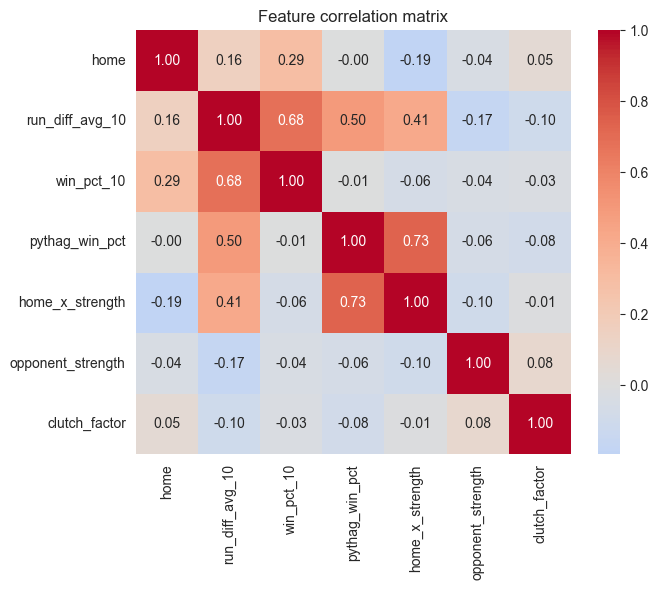

In [51]:
candidate_features = [
    "home",
    "run_diff_avg_10",
    "win_pct_10",
    "pythag_win_pct",
    "home_x_strength",
    "opponent_strength",
    "clutch_factor",
]

X_check = df[candidate_features].copy()

plt.figure(figsize=(7, 6))
sns.heatmap(X_check.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

### Baseline model + rolling-origin cross-validation

The original notebook used a single chronological 80/20 split, which on ~100 games is a thin basis for claiming the model beats the Pythagorean baseline. Rolling-origin CV retrains on an expanding window and evaluates on the next chunk repeatedly, giving a distribution of scores instead of one point estimate.

In [53]:
X_all, y_all = df[candidate_features], df["win"]

def rolling_origin_cv(X, y, min_train=30, step=10):
    scores, baseline_scores = [], []
    n = len(X)
    start = min_train
    while start + step <= n:
        X_tr, y_tr = X.iloc[:start], y.iloc[:start]
        X_te, y_te = X.iloc[start:start + step], y.iloc[start:start + step]
        if y_tr.nunique() < 2:
            start += step
            continue
        m = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
        p = m.predict_proba(X_te)[:, 1]
        scores.append(log_loss(y_te, p, labels=[0, 1]))
        if "pythag_win_pct" in df.columns:
            baseline_scores.append(
                log_loss(y_te, df.loc[X_te.index, "pythag_win_pct"], labels=[0, 1])
            )
        start += step
    return scores, baseline_scores

cv_scores, cv_baseline_scores = rolling_origin_cv(X_all, y_all)
print("Model log loss per fold:   ", [round(s, 3) for s in cv_scores])
print("Baseline log loss per fold:", [round(s, 3) for s in cv_baseline_scores])
print(f"\nModel mean log loss:    {np.mean(cv_scores):.4f} (std {np.std(cv_scores):.4f})")
print(f"Baseline mean log loss: {np.mean(cv_baseline_scores):.4f} (std {np.std(cv_baseline_scores):.4f})")
print("\nIf the model's mean isn't comfortably below the baseline's mean by more than about")
print("one std, treat the 'model beats Pythagorean baseline' claim with caution.")

Model log loss per fold:    [0.182, 0.275, 0.137, 0.173, 0.124, 0.094, 0.231, 0.026]
Baseline log loss per fold: [0.716, 0.7, 0.696, 0.695, 0.697, 0.702, 0.697, 0.703]

Model mean log loss:    0.1554 (std 0.0732)
Baseline mean log loss: 0.7008 (std 0.0066)

If the model's mean isn't comfortably below the baseline's mean by more than about
one std, treat the 'model beats Pythagorean baseline' claim with caution.


In [54]:
# Final model fit on all available data, for use in the simulation below
model = LogisticRegression(max_iter=1000).fit(X_all, y_all)

coeffs = pd.DataFrame({"feature": candidate_features, "coefficient": model.coef_[0]})
coeffs.sort_values("coefficient", ascending=False)

,feature,coefficient
6,clutch_factor,3.954447
4,home_x_strength,0.291394
0,home,0.070582
5,opponent_strength,0.037037
3,pythag_win_pct,-0.013790
2,win_pct_10,-0.180637
1,run_diff_avg_10,-0.261873


### Monte Carlo simulation of the rest of the season

In [56]:
full_schedule = load_team_data(TEAM, SEASON)
remaining = full_schedule[full_schedule["runs_scored"].isna()].copy()
remaining = remaining.sort_values("date").reset_index(drop=True)

today = pd.Timestamp.now()
remaining["opponent_strength"] = [
    team_win_pct_asof(opp, SEASON, today) for opp in remaining["opponent"]
]

# Build current_state fresh from the unshifted, fully-played games so every
# field reflects the same point in time (right now, after the last completed
# game) instead of reusing the shifted training row from df.
played = nats_raw[nats_raw["runs_scored"].notna()].copy()
played["win"] = (played["result"] == "W").astype(int)
played["run_diff"] = played["runs_scored"] - played["runs_allowed"]
played["games_played"] = np.arange(1, len(played) + 1)
played["runs_scored_cum"] = played["runs_scored"].cumsum()
played["runs_allowed_cum"] = played["runs_allowed"].cumsum()
played["run_diff_avg_10"] = played["run_diff"].rolling(10, min_periods=1).mean()
played["win_pct_10"] = played["win"].rolling(10, min_periods=1).mean()

current_state = played.iloc[-1].copy()
current_wins = int(played["win"].sum())
games_remaining = len(remaining)
print("Current wins:", current_wins, "| Games remaining:", games_remaining)

Current wins: 60 | Games remaining: 35


In [59]:
# Empirical run-margin distributions, split by win/loss, used to simulate
# a plausible final score for each simulated game (not just a binary outcome).
win_margins = df.loc[df["win"] == 1, "run_diff"].values
loss_margins = df.loc[df["win"] == 0, "run_diff"].values
league_avg_runs = df["runs_scored"].mean()  # rough per-game baseline to split margin into R/RA


def simulate_season(model, features, current_state, remaining, n_sims=10000, prob_adjustment=0.0):
    results = []
    for _ in range(n_sims):
        wins = 0
        rs_cum = current_state["runs_scored_cum"]
        ra_cum = current_state["runs_allowed_cum"]
        games_played = current_state["games_played"]
        run_diff_avg_10 = current_state["run_diff_avg_10"]
        # seed a rolling win-history window from the current win_pct_10 estimate
        win_hist = [1 if np.random.rand() < current_state["win_pct_10"] else 0 for _ in range(10)]

        for _, game in remaining.iterrows():
            run_diff_per_game = (rs_cum - ra_cum) / games_played
            pythag = rs_cum ** PYTHAG_EXP / (rs_cum ** PYTHAG_EXP + ra_cum ** PYTHAG_EXP)
            win_pct_10 = np.mean(win_hist[-10:])

            row = {
                "home": game["home"],
                "run_diff_avg_10": run_diff_avg_10,
                "win_pct_10": win_pct_10,
                "run_diff_per_game": run_diff_per_game,
                "pythag_win_pct": pythag,
                "home_x_strength": game["home"] * run_diff_per_game,
                "opponent_strength": game["opponent_strength"],
                "clutch_factor": game.get("clutch_factor", 0), 
            }
            X_game = pd.DataFrame([{k: row[k] for k in features}])
            prob = model.predict_proba(X_game)[0, 1]
            prob = np.clip(prob + prob_adjustment, 0.01, 0.99)

            win = np.random.rand() < prob
            wins += win

            # simulate a plausible score for this game and fold it into the state
            margin = np.random.choice(win_margins) if win else np.random.choice(loss_margins)
            rs = max(0, league_avg_runs + margin / 2)
            ra = max(0, league_avg_runs - margin / 2)
            rs_cum += rs
            ra_cum += ra
            games_played += 1
            win_hist.append(int(win))
            run_diff_avg_10 = 0.9 * run_diff_avg_10 + 0.1 * margin  # light smoothing, mimics a rolling avg

        results.append(wins)
    return results


sim_results = simulate_season(model, candidate_features, current_state, remaining, n_sims=10000)
final_wins = [current_wins + w for w in sim_results]

print("Expected Wins:", np.mean(final_wins))
print("Median Wins:", np.median(final_wins))
print("Min Wins:", np.min(final_wins))
print("Max Wins:", np.max(final_wins))

Expected Wins: 79.4075
Median Wins: 79.0
Min Wins: 71
Max Wins: 88


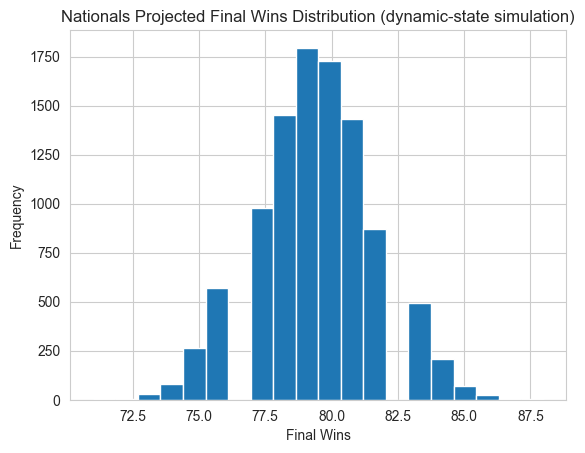

In [60]:
plt.hist(final_wins, bins=20)
plt.xlabel("Final Wins")
plt.ylabel("Frequency")
plt.title("Nationals Projected Final Wins Distribution (dynamic-state simulation)")
plt.show()

### WAR-based trade deadline adjustment

In [61]:
# "war_remaining" = projected WAR over the games remaining this season
# (not season-to-date WAR). Use a negative sign for players who left. Incomming are minor league callups, so we don't have a WAR estimate for them yet.
trade_moves = [{"player": "Luis Garcia Jr.", "war_remaining": -1.0, "direction": "out"},
    {"player": "Foster Griffin", "war_remaining": -0.8, "direction": "out"}
]

if not trade_moves:
    print("No trade_moves entered yet -- fill in the list above with real transactions/WAR.")
    prob_adjustment = 0.0
else:
    net_war = sum(m["war_remaining"] for m in trade_moves)
    WAR_TO_WINS = 1.0  # standard approximation: 1 WAR ~= 1 win over a full season
    net_win_impact = net_war * WAR_TO_WINS
    prob_adjustment = net_win_impact / max(games_remaining, 1)
    print(f"Net WAR impact: {net_war:+.2f} -> {net_win_impact:+.2f} wins over {games_remaining} games")
    print(f"Per-game win-probability adjustment: {prob_adjustment:+.4f}")

sim_results_adj = simulate_season(
    model, candidate_features, current_state, remaining, n_sims=10000, prob_adjustment=prob_adjustment
)
final_wins_war = [current_wins + w for w in sim_results_adj]

print("\nWAR-adjusted expected wins:", np.mean(final_wins_war))
trade_impact = np.mean(final_wins_war) - np.mean(final_wins)
print("Trade impact (wins):", round(trade_impact, 2))

Net WAR impact: -1.80 -> -1.80 wins over 35 games
Per-game win-probability adjustment: -0.0514

WAR-adjusted expected wins: 78.0412
Trade impact (wins): -1.37


### Team performance context

In [62]:
current_wins = int(played["win"].sum())
games_played = len(played)
current_win_pct = current_wins / games_played
projected_wins_actual = current_win_pct * 162

total_runs = df["runs_scored"].sum()
total_runs_allowed = df["runs_allowed"].sum()
pythag_win_pct_season = (
    total_runs ** PYTHAG_EXP / (total_runs ** PYTHAG_EXP + total_runs_allowed ** PYTHAG_EXP)
)
pythag_wins = pythag_win_pct_season * 162

print("Games played:", games_played)
print("Current wins:", current_wins)
print("Current win %:", round(current_win_pct, 3))
print("162-game win pace:", round(projected_wins_actual, 2))
print("Pythagorean win %:", round(pythag_win_pct_season, 3))
print("Pythagorean projected wins:", round(pythag_wins, 2))
print("Difference (win pace - Pythagorean):", round(projected_wins_actual - pythag_wins, 2), "wins")

Games played: 126
Current wins: 60
Current win %: 0.476
162-game win pace: 77.14
Pythagorean win %: 0.515
Pythagorean projected wins: 83.36
Difference (win pace - Pythagorean): -6.22 wins


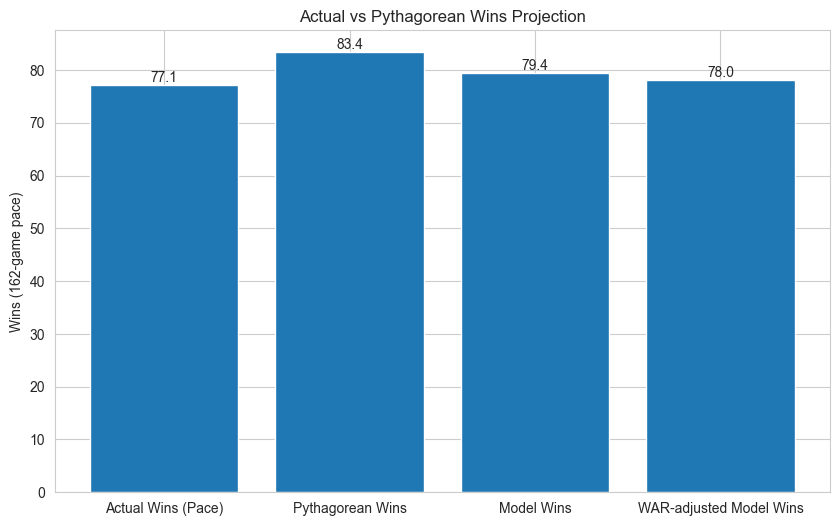

In [66]:
import matplotlib.pyplot as plt

labels = ["Actual Wins (Pace)", "Pythagorean Wins", "Model Wins", "WAR-adjusted Model Wins"]
values = [projected_wins_actual, pythag_wins, np.mean(final_wins), np.mean(final_wins_war)]

plt.figure(figsize=(10, 6))  # Adjusted figure size

bars = plt.bar(labels, values)
plt.ylabel("Wins (162-game pace)")
plt.title("Actual vs Pythagorean Wins Projection")

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}", ha="center", va="bottom")

plt.show()

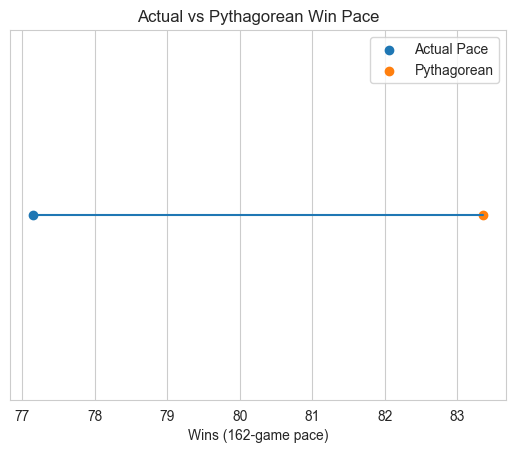

In [67]:
import matplotlib.pyplot as plt

actual = projected_wins_actual
pythag = pythag_wins

plt.figure()

# line between points
plt.plot([actual, pythag], [1, 1])

# endpoints
plt.scatter(actual, 1, label="Actual Pace")
plt.scatter(pythag, 1, label="Pythagorean")

plt.yticks([])
plt.xlabel("Wins (162-game pace)")
plt.title("Actual vs Pythagorean Win Pace")
plt.legend()

plt.show()

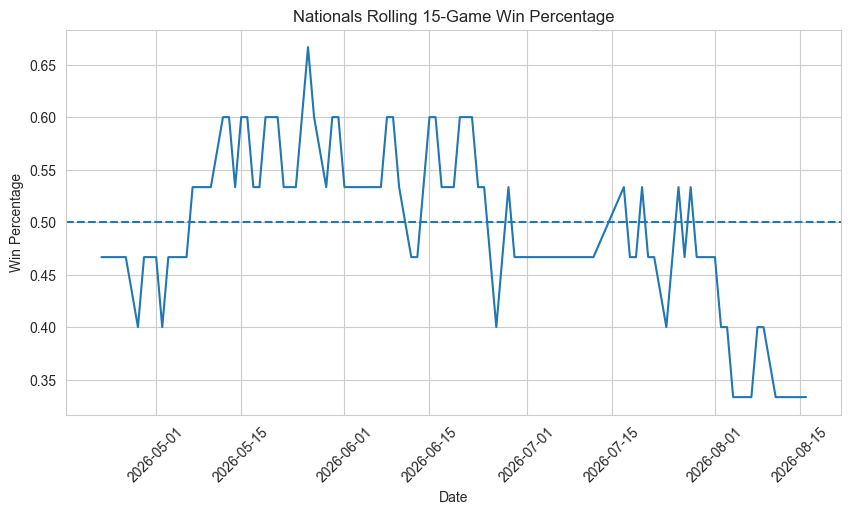

In [68]:
df["rolling_win_pct"] = df["win"].rolling(15).mean()

plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["rolling_win_pct"])
plt.axhline(0.500, linestyle="--")
plt.title("Nationals Rolling 15-Game Win Percentage")
plt.xlabel("Date")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)
plt.show()

### Prediction intervals & summary plots

In [69]:
print("Mean wins:", round(np.mean(final_wins), 2))
print("Median wins:", round(np.median(final_wins), 2))
print("Standard deviation:", round(np.std(final_wins), 2))

lower_90, upper_90 = np.percentile(final_wins, [5, 95])
lower_50, upper_50 = np.percentile(final_wins, [25, 75])
print(f"90% prediction interval: {lower_90:.1f} - {upper_90:.1f}")
print(f"50% prediction interval: {lower_50:.1f} - {upper_50:.1f}")

Mean wins: 79.41
Median wins: 79.0
Standard deviation: 2.21
90% prediction interval: 76.0 - 83.0
50% prediction interval: 78.0 - 81.0


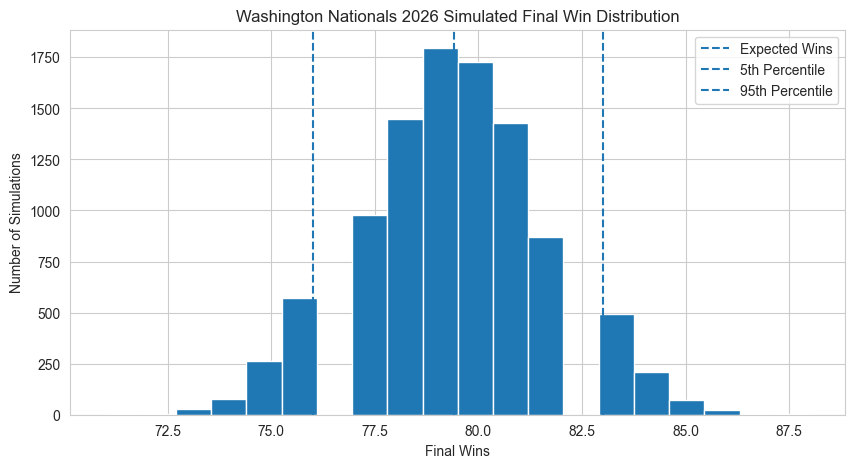

In [70]:
plt.figure(figsize=(10, 5))
plt.hist(final_wins, bins=20)
plt.axvline(np.mean(final_wins), linestyle="--", label="Expected Wins")
plt.axvline(np.percentile(final_wins, 5), linestyle="--", label="5th Percentile")
plt.axvline(np.percentile(final_wins, 95), linestyle="--", label="95th Percentile")
plt.xlabel("Final Wins")
plt.ylabel("Number of Simulations")
plt.title("Washington Nationals 2026 Simulated Final Win Distribution")
plt.legend()
plt.show()

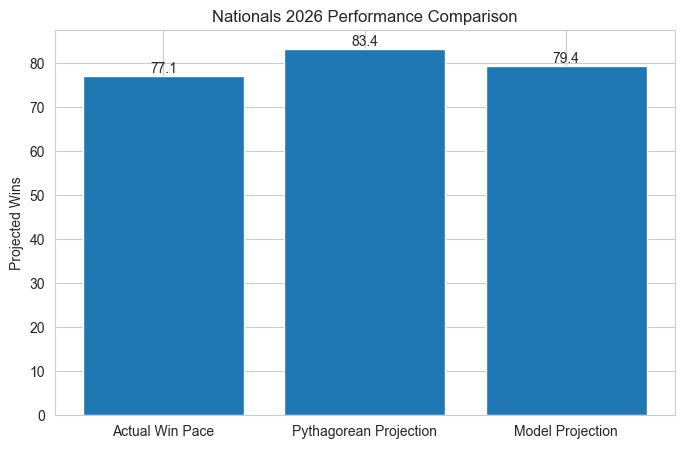

In [71]:
labels = ["Actual Win Pace", "Pythagorean Projection", "Model Projection"]
values = [projected_wins_actual, pythag_wins, np.mean(final_wins)]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylabel("Projected Wins")
plt.title("Nationals 2026 Performance Comparison")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}", ha="center", va="bottom")
plt.show()

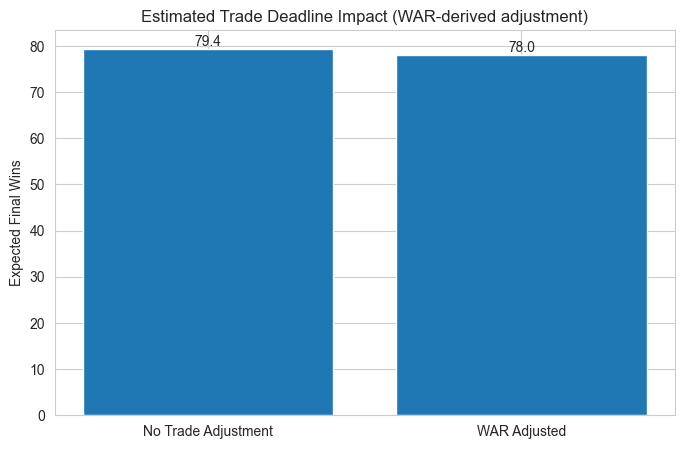

In [72]:
scenarios = ["No Trade Adjustment", "WAR Adjusted"]
wins = [np.mean(final_wins), np.mean(final_wins_war)]

plt.figure(figsize=(8, 5))
bars = plt.bar(scenarios, wins)
plt.ylabel("Expected Final Wins")
plt.title("Estimated Trade Deadline Impact (WAR-derived adjustment)")

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}", ha="center", va="bottom")

plt.show()

In [73]:
df["rolling_win_pct"] = df["win"].expanding().mean()
df["projected_wins_to_date"] = df["rolling_win_pct"] * 162

In [74]:
preseason_projection = 60 

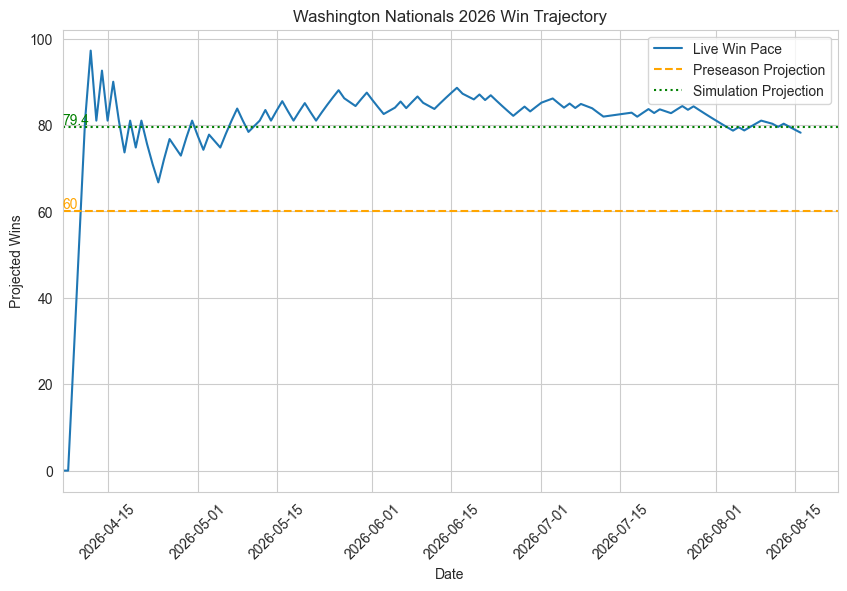

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Rolling projection over season
plt.plot(df["date"], df["projected_wins_to_date"], label="Live Win Pace")

# Preseason baseline (flat line)
plt.axhline(preseason_projection, linestyle="--", color="orange", label="Preseason Projection")

# Final simulation projection
plt.axhline(np.mean(final_wins), linestyle=":", color="green", label="Simulation Projection")

# Start chart at first loss
# Calculate the first loss date
first_loss_date = df.loc[df["result"] == "L", "date"].min()
plt.xlim(left=first_loss_date)
plt.xlabel("Date")
plt.ylabel("Projected Wins")
plt.title("Washington Nationals 2026 Win Trajectory")
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Add data labels for the horizontal lines
plt.text(df["date"].min(), preseason_projection, f"{preseason_projection}", color="orange", va= "bottom")
plt.text(df["date"].min(), np.mean(final_wins), f"{np.mean(final_wins):.1f}", color="green", va="bottom")

plt.show()
